# Test LaguerreDensity Approximation Quality

In [115]:
import numpy as np
import matplotlib.pyplot as plt
from LaguerreDensity import LaguerreDensity
from ajdmom.mdl_srjd.euler import rSRJD_exact
from ajdmom.mdl_srjd.cond_cmom import m_to

# Parameters
theta = 0.008
theta = 0.018
v0, k, sigma = 0.007569, 3.46, 0.14
lmbd, mu_v, h = 0.47, 0.05, 1.0

par = {'v0': v0, 'h': h, 'k': k, 'theta': theta,
       'sigma': sigma, 'mu_v': mu_v, 'lmbd': lmbd}

exact_samples = rSRJD_exact(v0, k, theta, sigma, lmbd, mu_v, h, 1000000)
print(f'Feller condition need: {2*k*theta:.7f} > {sigma**2:.7f}')
if 2*k*theta <= sigma**2: print('Feller condition is not satisfied')

mean_v = theta + lmbd * mu_v / k
ratio1 = round(100 * theta/mean_v, 1)
ratio2 = round(100 - ratio1, 1)
print(f'theta contributes {ratio1}%, jump contributes {ratio2} % of E[v]')

Feller condition need: 0.1245600 > 0.0196000
theta contributes 72.6%, jump contributes 27.4 % of E[v]


In [116]:
moms = m_to(16, par) # including the 0th moment
moms = moms[1:]
print(moms)

[0.024250595630007317, 0.000994531774951021, 8.007963179038874e-05, 1.1193591753799307e-05, 2.22191545994817e-06, 5.60323129811186e-07, 1.701374898892781e-07, 6.029219695522841e-08, 2.4408136934457712e-08, 1.1109460277147494e-08, 5.6146924766177876e-09, 3.1194569072723963e-09, 1.8895861519771018e-09, 1.2393205943324564e-09, 8.749295160383081e-10, 6.615041369184424e-10]


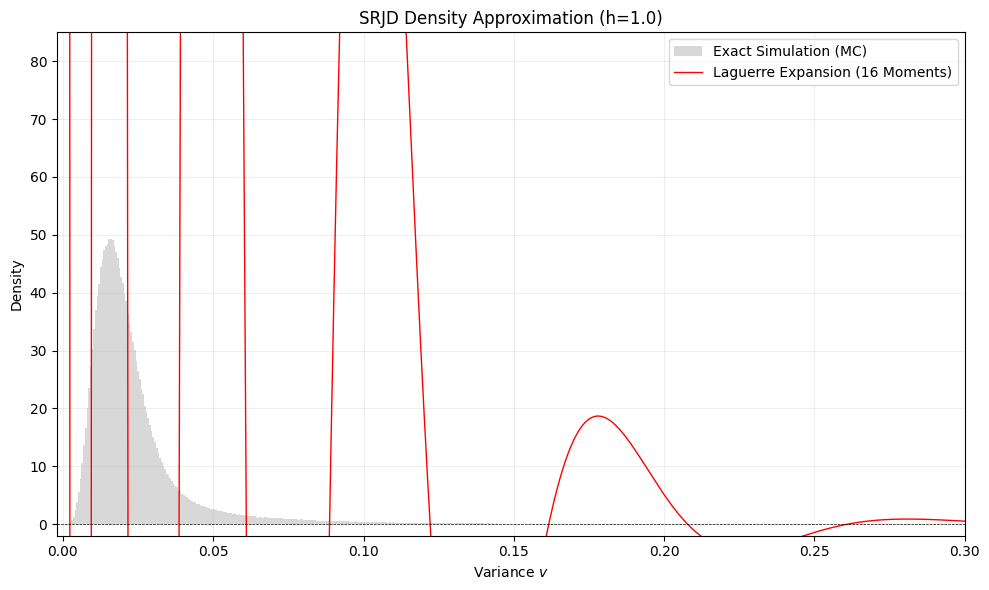

In [117]:
approx = LaguerreDensity(moms)
# Plotting
# ... 承接之前的计算代码 ...
plt.figure(figsize=(10, 6))

# 计算一个合理的显示范围：取 99% 分位数或手动指定
x_limit = 0.3

# 重新生成网格，确保左侧边界渲染精细
v_grid = np.linspace(1e-4, x_limit, 1000)
# v_grid = np.linspace(0.00561, x_limit, 1000)
pdf_approx = approx.pdf(v_grid)

# 绘图
plt.hist(exact_samples, bins=1000, density=True, alpha=0.3,
         color='gray', label='Exact Simulation (MC)')
plt.plot(v_grid, pdf_approx, 'r-', lw=1,
         label=f'Laguerre Expansion ({len(moms)} Moments)')

# 核心：精细控制坐标轴
plt.xlim(-0.002, x_limit)  # 稍微留一点左白，看清边界
plt.ylim(-2, 85)           # 限制 Y 轴，防止留白过多，同时容纳峰值

plt.axhline(0, color='black', lw=0.5, ls='--') # 参考线，检查是否有负值
plt.title(f"SRJD Density Approximation (h={h})", fontsize=12)
plt.xlabel("Variance $v$")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

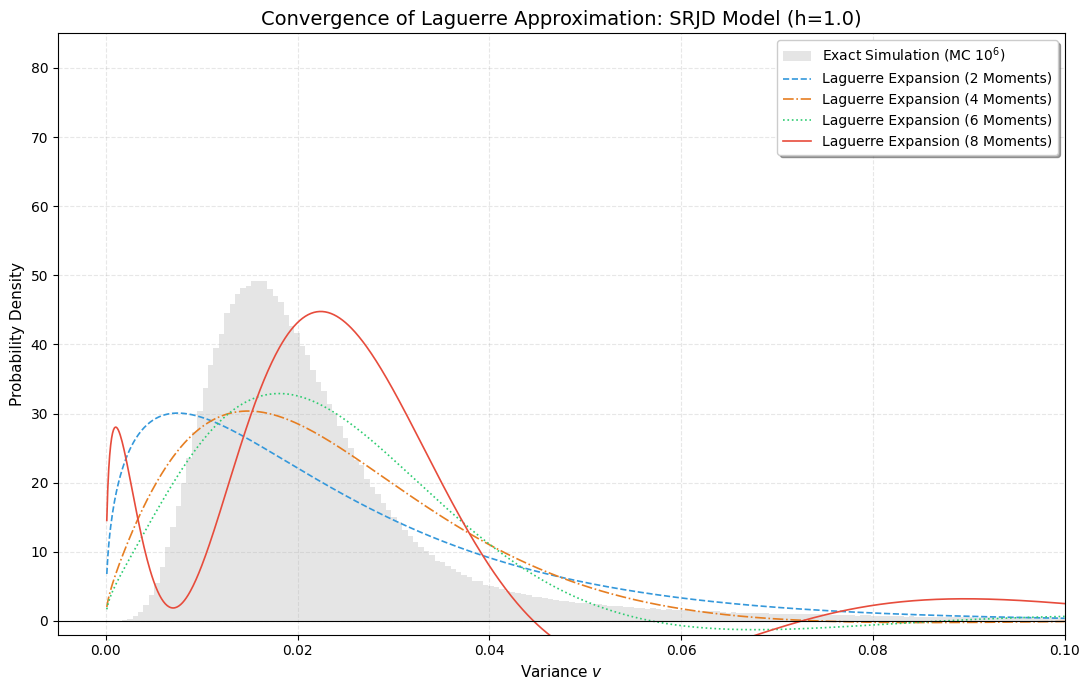

In [121]:
# --- 1. 准备数据 ---
# 假设已经生成了 exact_samples
# 计算最高到 14 阶的矩，供后续截取使用
all_moms = moms

# --- 2. 设置绘图参数 ---
plt.figure(figsize=(11, 7))

# 画背景直方图（只需画一次）
plt.hist(exact_samples, bins=1000, density=True, alpha=0.2,
         color='gray', label='Exact Simulation (MC $10^6$)')

# 定义我们要对比的阶数、颜色和线型
n = len(moms)
n = 8
orders_to_compare = [n-6, n-4, n-2, n]
colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c'] # 蓝、橙、绿、红
linestyles = ['--', '-.', ':', '-']

x_limit = 0.1
v_grid = np.linspace(1e-4, x_limit, 1000)

# --- 3. 循环构造并绘图 ---
for order, color, ls in zip(orders_to_compare, colors, linestyles):
    # 只取前 'order' 个矩进行构造
    current_moms = all_moms[:order]
    approx = LaguerreDensity(current_moms)

    # 计算密度
    pdf_vals = approx.pdf(v_grid)

    # 绘图：阶数越高，线条设得稍微粗一点以示强调
    lw = 1.2 if order < 12 else 2.0
    plt.plot(v_grid, pdf_vals, color=color, linestyle=ls, lw=lw,
             label=f'Laguerre Expansion ({order} Moments)')

# --- 4. 细节修饰 ---
plt.xlim(-0.005, x_limit)
plt.ylim(-2, 85)  # 根据您之前的观察，峰值在 70-80 之间，这个范围很合适

plt.axhline(0, color='black', lw=0.8, ls='-')
plt.title(f"Convergence of Laguerre Approximation: SRJD Model (h={h})", fontsize=14)
plt.xlabel("Variance $v$", fontsize=11)
plt.ylabel("Probability Density", fontsize=11)

# 将图例放在合适的位置，避免遮挡峰值
plt.legend(loc='upper right', frameon=True, shadow=True, fontsize=10)
plt.grid(True, which='both', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

## Pearson

{'A1': np.float64(2.0546869426555943),
 'A2': np.float64(0.38385017826384304),
 'A3': np.float64(-2.4385371209194378),
 'B3': np.float64(2.612172753803403),
 'type': 44,
 'x1': np.float64(-0.006887547801397943),
 'x2': np.float64(0.012737047027384733),
 'x3': np.complex128(0.5337031974439572+0.2659474134299894j)}
a = -0.009798693018004897, scale = 14.777747067903634, is_max: False
pdf(-a) = 1.0000000


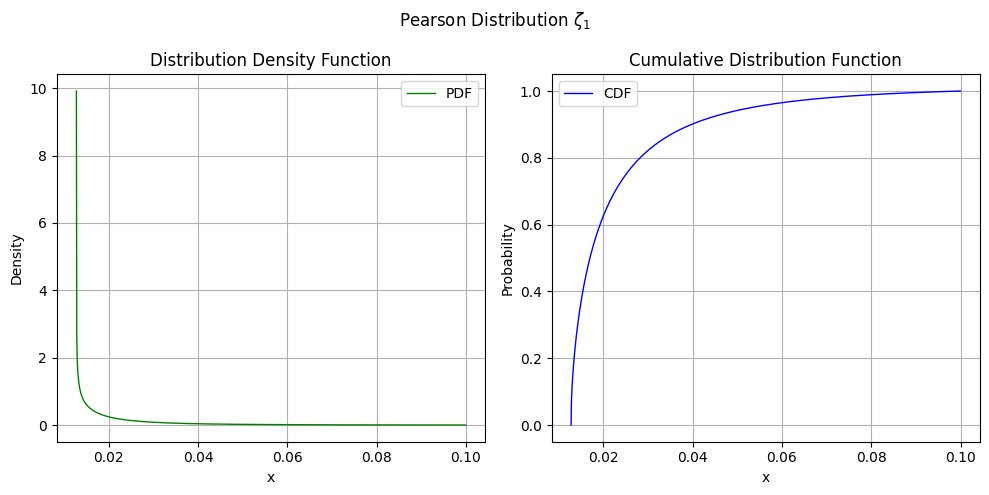

pdf(0.0127400) = 9.91e+00, pdf(0.1000000) = 2.84e-03


In [120]:
from pearsondist import Pearson8
from pprint import pprint
from utils import plot_dpdf_pdf, plot_pdf_cdf

pearson = Pearson8(moms[:8])
pprint(pearson.pfd)
print(f'a = {pearson.coef[0]}, scale = {pearson.pdf_obj.scale}, is_max: {pearson.pdf_obj.is_max}') # print("coef: ", pearson.coef)
print(f'pdf(-a) = {pearson.pdf(-pearson.coef[0]):.7f}')
# lbub = pearson.determine_bounds()
lbub = (0.01274, 0.1)
x = np.linspace(lbub[0], lbub[1], 1000)

pdf = pearson.pdf(x); title = r'Pearson Distribution $\zeta_1$'
plot_pdf_cdf(x, pdf, title)
dpdf = pearson.dpdf(x); title = 'PDF and its Derivative'

print(f'pdf({lbub[0]:.7f}) = {pearson.pdf(lbub[0]):.2e}, pdf({lbub[1]:.7f}) = {pearson.pdf(lbub[1]):.2e}')